# 23/23 Strict-Future | v23 Sparse Closed Loop

**A current Top-30 route refresh, an exact future-engine detector,
and only the feedback branches that survived holdout.**

The public v22 artifact is still highly visible, but its route won
only **3/23** on public episodes created
after this study's route candidates were frozen. A current complete
route plus order-safe market feedback reached
**23/23**.

| Chronological current-engine gate | Wins | Seat 0 | Seat 1 |
|---|---:|---:|---:|
| development | 30/30 | 20/20 | 10/10 |
| untouched current Top-30 outer | **42/45** | 21/23 | 21/22 |
| episodes created after freeze | **23/23** | 11/11 | 12/12 |
| frozen main.py, exact replay | **23/23** | 11/11 | 12/12 |

The title is a **local strict-future counterfactual replay result,
not a Public-LB score**. Recorded opponents do not react to our
counterfactual actions.

    current engine: Azelearn route + price-impact SELL ordering
    PR #1394 engine: Khanh route + demand-aware SELL ordering
    both: observed WEED repair, fixed quantities, fixed BUY/HIRE slots

## Machine-readable contribution and attribution card

    upstream_public_agent: Kaito v22 Price Impact
    legacy_route:
      team: Azelearn
      submission: 55310687
      episode: 90621805
      seat: 1
      action_sha256: c2dff1dff8647c0066a7ba2e43c18dc5c28616c1f664263d1239129caeddfd72
    rebalance_route:
      team: Khanh
      submission: 55313104
      episode: 90638404
      seat: 1
      action_sha256: dfdf97295b5521646b872790247ebc73984fe7e05f9814128c4e933a6cee80f0
    new_contribution:
      - exact official configuration regime detector
      - public-state encoder with duplicate-shop demand
      - exact lightweight market rollout
      - seed-grouped route-gate rejection experiment
      - conservative demand-aware ordering inside SELL slots
      - two-regime artifact equality verification
    runtime_identity_fields: []
    runtime_opponent_private_fields: []

The backbones are public Azelearn and Khanh trajectories. This
Notebook does not relabel them as newly discovered schedules. The
contribution is the empirical branch boundary, lightweight control
layer, negative ablations, and reproducible submission artifact.

## 1. The balance change is real; the live engine has not changed yet

The host's
[official announcement](https://www.kaggle.com/competitions/kaggriculture/discussion/733431)
links
[Kaggle environment PR #1394](https://github.com/Kaggle/kaggle-environments/pull/1394).
It makes two strategic changes:

1. Town Center buys one unit once per day, with no day-10/day-20
   multiplier.
2. Shops are sampled with replacement; duplicate instances each
   contribute demand.

At this artifact's freeze time the PR was **open**, while the live
competition used kaggle-environments 1.32.4. The agent therefore
reads the official townCenterSellInterval configuration:

| Configuration | Engine branch |
|---|---|
| 12 | current legacy route and controller |
| 24 or higher | announced rebalance route and controller |

This is deterministic and forward-compatible. It does not guess
from the date, team, score, or Notebook identity.

## 2. First diagnosis: the public route became stale

A fresh 2026-08-07 official Top-30 snapshot produced 105 unique
public episodes. Complete fit-only trajectories were screened on
later trajectories, preserving time order.

| Current-engine policy | Development | Untouched outer | Strict future |
|---|---:|---:|---:|
| stale public v22 route | 5/30 | 7/45 | **3/23** |
| Azelearn route only | 30/30 | 40/45 | — |
| Azelearn + impact slots | **30/30** | **42/45** | **23/23** |
| Khanh + impact slots | 30/30 | 42/45 | 23/23 |

The new leading basin is livestock-heavy. Azelearn and Khanh share
556/719 exact turn actions and an exact 168-turn prefix; Azelearn
and the stale Kaito route share only 5/719. This proves a
low-entropy meta, but not whether every participant copied or
independently converged.

The current branch uses Azelearn because win counts tied and it had
the higher untouched/future mean margin. The major gain is route
refresh. Closed-loop sophistication is not credited for that gain.

,policy,wins,games,mean margin,win rate
0,stale public v22,3,23,-3228.391304,0.130435
1,current route only,40,45,2585.422222,0.888889
2,v23 legacy branch,42,45,3249.444444,0.933333


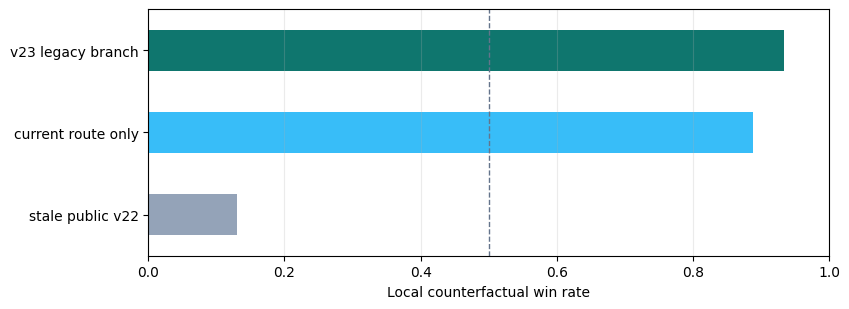

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

current_results = pd.DataFrame([
    ["stale public v22", 3, 23, -3228.391304347826],
    ["current route only", 40, 45, 2585.4222222222224],
    ["v23 legacy branch", 42, 45, 3249.4444444444443],
], columns=["policy", "wins", "games", "mean margin"])
current_results["win rate"] = current_results.wins / current_results.games
display(current_results)

ax = current_results.plot.barh(
    x="policy", y="win rate", legend=False, figsize=(8.6, 3.2),
    color=["#94a3b8", "#38bdf8", "#0f766e"],
)
ax.axvline(0.5, color="#64748b", linestyle="--", linewidth=1)
ax.set(xlabel="Local counterfactual win rate", ylabel="", xlim=(0, 1))
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 3. Did random shops make production-route switching valuable?

We reproduced PR #1394 locally, then ran both seats against three
strong public routes on disjoint seed groups.

| Rebalance backbone | Seeds 0–15 | Seeds 16–31 |
|---|---:|---:|
| Khanh | **87/96**, +4,149 | **76/96**, +332 |
| Azelearn | 86/96, +3,311 | 76/96, -24 |

Across 32 seeds, all 32 final shop compositions were distinct,
31/32 contained duplicates, and only 5.31 of eight instances were
unique on average. State variance undeniably increased.

But an identity-free ridge value gate selected Khanh in
**96/96** holdout cases.
It scored exactly 76/96—the same
as fixed Khanh—and made zero useful switches. Even the train
margin-oracle did not add a win over fixed Khanh.

**Result:** shop randomness increased, but route-level value of
information was not demonstrated. The learned route switch is not
in main.py.

## 4. What events actually change an action?

We applied finite differences to 1,056 real
public observations at every Khanh turn with at least two SELLs.
All production actions and nonperturbed state stayed fixed.

| Perturbation | SELL-order branching |
|---|---:|
| market inventory -30% | **50.19%** |
| market inventory +30% | **37.50%** |
| legacy versus rebalance regime | 3.79% |
| three copies of one shop | 0.76%–1.89% |
| own cash -30% | 0% |
| opponent milk assets +3 | 0% |

These are controller sensitivities, not claims of globally optimal
farm actions. They locate the useful feedback boundary: market
inventory is a strong order-level trigger; duplicate-shop demand is
a sparse secondary trigger; cash and opponent assets do not belong
in this narrow controller without a direct value test.

    score = official self-induced price impact
            × (1 + 0.25 × bounded inventory recovery time)

The demand term is active only after the balance change and counts
duplicate shop instances.

## 5. Negative result: market-only quantity MPC is a trap

The simulator exactly implements the official nonlinear price
curve, unit-lockstep SELL revenue, shop ticks, and Town Center
ticks. We used it to evaluate delayed or resized sales.

| Rebalance development controller | Wins |
|---|---:|
| impact ordering | 58/60 |
| quantity MPC, switch cost 100 | **4/60** |
| quantity MPC, switch cost 250 | 20/60 |
| quantity MPC, switch cost 500 | 50/60 |

Quantity is coupled to later BUY/HIRE affordability, actor timing,
opponent supply, and terminal stock. A market-only value model
omits those effects. More search over the same wrong objective
would only optimize the mistake.

On an untouched 90-game rebalance outer set, the conservative
demand term kept 84/90
wins and changed mean margin from
4,406.6 to
4,419.7. Because the gain is small,
alpha is capped at 0.25 and SELL quantities remain frozen.

## 6. The promoted sparse engine

    official configuration
        ├── interval 12: Azelearn current-meta backbone
        └── interval 24: Khanh rebalance-robust backbone
                        ↓
                 observed WEED repair
                        ↓
           current market inventory and quote
                        ↓
       rank only existing SELLs inside SELL slots
                        ↓
             execute one action and observe again

Safety invariants:

- ordinary turns create, delete, and resize no SELL;
- every BUY/HIRE and non-SELL slot remains in place;
- farmer and hands follow one complete validated trajectory except
  for an observed WEED transaction repair;
- no opponent name, team ID, submission ID, episode ID, seed,
  Notebook identity, or private opponent inventory enters runtime;
- Python standard library only.

Pure closed-loop, learned route gating, quantity MPC, and terminal
liquidation were all tested and rejected. Complexity is not a
result; a holdout win or robustness improvement is.

## 7. Community context and citation boundary

This release builds on and cites:

- [Kaito v22 Price Impact](https://www.kaggle.com/code/kaitofukami/44-46-strict-future-top-30-v22-price-impact):
  the public upstream controller and stale baseline.
- [Rayk Kretzschmar — Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta):
  careful replication boundaries and market-order analysis.
- [beicicc — C20 Exact Replication Control](https://www.kaggle.com/code/beicicc/kaggriculture-c20-exact-replication-control):
  replication as a control rather than an unlabelled contribution.
- [prvsiyan — The Moon Counts Melons](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-the-moon-counts-melons):
  a strong alternative public frontier and reminder to test full
  capital/production timing.

The complete routes below remain attributed to Azelearn and Khanh.
Forks should keep those route citations, cite this Notebook for the
regime/market controller, and report their own changed mechanism
and chronological holdout.

In [2]:
import base64
import hashlib
from pathlib import Path
import tarfile
import zlib

encoded = "".join((
    'c-pkP*|w@&vn_c4J;m}DJb-QPCQ6|R7Kow<79gT{p@K>!HKJnm?CHPva_+NFUgS;YyjYDjCqy4H7$YKjjLyIQ^{-',
'2{_9u<>Bt8DwdtrJ!{CHs){n4#saQ<V4$sa+tti;)8-Z@K-|MAa1ihcZJ>WTj+^7P=3lm1DM-',
'f@3E9{z;E{`03K^#7bc_k^bD>>b_va||pe_*f4E)3LHdKRaRYfBp0CThjB#@cGBg{%!gXbN?99li*JhX6NI7V*mRl?`Y}!{A)!I4',
'*&Vv^!OQR5*k^0{ztI&!2Um;(t{w(KI1w3naO{OXsv<$NsgA|AOGXeA2|!opQ}IS$A+QrPycqpbA0FH!$0TnkG?;L$!8Y!pRr#*w',
'|pMlhnHiL|0j5u9FB<-SbvT;Cq4iBV%`_UKdBd<(?3T3KV1JO`uO+pJWDRe&va$!AN`N<8P?%r^l<b)=6-',
'%{pO2p@b%OtVJ~<ltXL9$)@0kDj*T4StkK;#Sa{goJ>5;&`|J#RA{=Ih7F!)~k`q}<o-',
'#y3p=bwMJVt>G}+LmDzema@|Y5wN}|KWxDA%*^Z&wm^~gYl!}n5NKwq5OwY$N&Ay!x8%D&*$gA{{3J3pa1n=7s-',
'j9wu~`?mkbrsUyeN1=pn*QkB?|p+ohyfHx#tj8?aE&9SyywS>xr5_TGipz?sdF<8npqr_pv`K29&PTGEU{FPa{)@}^!<7Z2!UOiR',
'IEC=N!}=0lmUdN|*wVGOS!%JL+0<Fs|#p7gHNe&r54%QnZ!StbH_p-',
'R~}X$lFWw9FS`WEYG)fa_$~&lhXIz43k5V%Bu++z`li=3LxqJNyeZUcScZWIoH$aqBu5yZrO9MS91t(}G%La;2t7_nZgknH;Juvx',
'{f(HdK@Iy1DvE&ZC#8tQFY6j7j&Jo<+I~kvSuU`P_@xQSo(Vj1Aj9NgaIIue#uA`L#XuW58tEnQ)McUM_STY4hm0=kP~VPHnJQKb',
'uX;yG(bly*+K+Do~Uh5D)J7X=i;B7ppq8)y$Pg6vwBdu@XL$0JW~eN7eDHIY>)PUF+jtsIox5?4<rMpuGiYJGs=`SID@1A~%%7z<',
'GP#gWBd|R$uRuq|MgQaCih24$jfbZF8+ouE+3xBDUnBw!4w)ctu%@w?HmIGb`%@X{%5{{&V~b#faqb6o_4QH*c}+&b4EI2T>PCgY',
'n1+EK00aZorvo<Mnc_4fq}R(d(^al3fjfp51qAUF}XU>Qfm&j{faf+hD+EajK%Zs3`|Joe=~=dM&7{H)q;)+L-',
'O=?yRtkr}H!Q7pms=Bc_+Ilm4Qy>0|hgJJ>CyhL+l;Go}p7vxxGqFal{)rGbs-',
'd~Mx$bZhou(76m~81xcwpqGoM#x%e%JTTO2mspqXF~Frn-K<|jOHH-!)S7ds_L$Y$?c^FkOi+!EJ-',
'^Lr{ld0oYU_HlKOt)?{j4YIqP^ysA%ExlL!#Ds>xFZLonI$`WCN9XlW+$TJ^Z<Rr>lACwu6(DHEvRKhahvo^wbKoo9+9x@(Hmk9=',
'E_>^(upNR?G6dqA?KrX1o5b?iY=zTIiS)@R8>iXghCN`{TZO+1<gE9!`T6&yL#w--_$%U#Qa{<yNh!%+)HK4$w55^$x4#QGVeh)o',
'DJq`P3R+9PGIQ&#MJYhIPop-',
'N~`SjvgDHggWlP#VKl4OA>7%*kWh1ovSY!NxrW1mr7C}Etx`vi&2u*<Oy>*a%+H!J3szH8)17F8)c*U)|x#qgr`~>qicF$b3YHM$',
'*?iq@!clTt<&Q1^!~{nW=2%l?v24P#{<3?&n5>|HuGLuI1H?3ZuA~ET^Al6S){geYTa2$&V`{@KZ9UcSES={(w&^DK+=E2+&Gvm3',
'@9w*_(CD8BY?#R+ppQItKfI)Qj({X-D@p<7pX6Zq*s3y*<pIE-',
'p=;V!|u1CWAc2Sx<8J1+A~!%4bT4aXsVp~(u&G)aEctPSWQtGpL`8pQdLrx15X&6&B;z5Ffj@*=PEE{CZ2Eg@!YCU!&e1SJDi1J6',
'B~H)ePR7*Ee7J2yC?mAbu=OJczh@Y@5R$P_qvhW_!@VIM_PBq^<Xdb8K|nn)X=qXY}^#~IZk=+^eVrmqkeDb3>r<YJoOPzZW-',
'J0b(Zh12H^$L3+qfP0emm_j^lji4t?$t-',
'=_z=43Cu=kQ{2?{eEFj%Rx&^^eZ<d#zp9bV=v$4(gU1O!E3P~<D#6Ea`3VRyA9qjYwrP5nPis(dOf_OXJ8h~Y;$>@ta|Iiy=6u{c',
'Bs$A9WAES`i3Mcr8PSG3q>W(g<6JptL%c8t3%!<i)VPcyA>u;I=*PXD`Br8GqyJm`y(Pp?QFAJ_EM@|e(Ywrk{CPN>ewrUFY@aEZ',
'#T?->%ui3jSdIB5!2vKy*t&L7MqdZG@Jd+sVQ9(&xLZSOiTr=;>;Qq!;Jqzy}L-',
'I(`JuB9N%B2dniFOPorCz;4e$)!JR}U1nb=@ahnsm<l*F-9vENs3c9%Ng&fcBI<t|-',
'{XuPqPi=6aTBBJui6UJ?p6e_;x5DXiHvJ1la`o!57d$pT=GNnihaFm~ICXt|dBqs-vvz0YoqCQ(Y2m&t(^ee6#EhHBDE_;YjdWcy',
'cK32}PIPkuaib+Z75hm0FgIz8$Ma2#Q_;BZ+Z8!uF)LW9jzx|{^CldU?V3otTBmmIbE$dAxy@;g6(&e)lfes@Q0L{nRD=)c>Mztp',
'X{xn;)fTtHc)1>+B^%ic@)eTPWU1$L=<kpYeYOs-{L`p3sv|~Pw;$Q0S6agRq!P&R0~)dmv`1LA-L-',
'iC<il0CY`KH-u^^9hMz;#Fz!~f1iX|6&VN2B~A%amhI{?6RHQs?xWo&$bbm50dhEtvqI!0k7ZGlLeG?f!z)SFv@B|PCQR-LAz5ty',
'FZ3Wde`^|Qf$XRfR_#QIXMZYD~3_4XX8ZfuB(*W$rw^QPPDLzW&gQJuiXg8*RrIBZpu2NEmG+0ZW2c`Ewz2L_$*HOsPw(@bv>=y=',
'+h!rsKJA8*!ndN%(;wJW<RR1CRwDy28Sngrp6RgBA^@m$<`hjX`os8>dnTjjRF{Cm65vo+sTN=e}~9RQ+k*g#vGYA@Omchn}qCb3',
'pGK%3ot)>Nl2O$QQ8*_*#mK;B#(3h~qwE5RUo7lf#-=hyzWd}Q-',
's<GJ+{Aug70i>n(LL2oh)7Eiaz;?AZ|6wXuw*VnNUfumFs*brKj-|E9XI%fx0)|dNCa@cB*S%32}U=(Ety{-',
')VY|fxzKAUup4Gdh^H>r!P4l>9ceOY=n+imGm+;=^rRN#7z5j}`#fZo<sM0K{r5o*=(QDZx<w&GzQehlRN$8+`XTY8<k1)#PQ<z@',
'jWRD#N-Eul`NF`j`_1kJw+L4Y62n+e?;Uy6ROx1jYU!5v)Q-',
'!16$j+^v(K3}#Mmt$^M)LOfP@?CrLwQh;&U={5aRMSAwn7qSE^ysY$$HCdv#&;XXU%O#p9np-',
'{eH#F(Rf*K={yct4y@5t44f$Om4q2!BUbPqZwtp+kyr}A8oe<o4<NB`;mBy=dpw~TkvfPK$E8Re`YfK)R^rp)mW!-',
'DEoAfe}=tWa`A$G?1!`m!sDZQoZjP*jf!3GA^U_=Oe4ojEj?xMzb-vw`~|D)deW4<H3(Z<&ywXSzNUaBm*!@G`DdOvmw!m1k@^84',
'YR-',
'2Q#pWypy+3AC|oyk{WIp)GlJl#`z>nv6@Ay3pK}z@E+1!JrVsySg!e2=qvEcZlLI>DQ%sJ(8PXRSLuEaR{G}mVkw`@oSGLTkt*&D',
'NSy_e{yd$T8*24CC|Ul1(A3aS3kS;<i>DPzN%IxKYg$bO_7tHwN}fxc_=TbZ4g)cn{rYZL2ZJ;&9d&!O$f)pxDlSbJ-',
'8hAkClL({ubTVo_SV6-',
'Yv^udww69OIoQqMMoNYYT`5ROBp~9rxT!|*P%;~#@mP=3?pOl!$k~#z5`Q+7wgoB<V4|O)qU=>4lBQ5;&zO?*`<dzcG|?6JBvX)I',
'$^cxt-b6SK6EsI*Sg*?>S{UoB=*I-',
'9Y!7EgiHtOE{QHQ_qDSTuzpD6UV`+DDT3~Y^^t&{dcnJTJk{LNTBwKv*=tAaWcpmOJ)d(z;Q?ZrvhXTe?@ETjf!_lJkCf3TelyC2',
'E!B%{)j0B;(YXY>$tukMLd}YNBOKk?+p#E!H?vaWX6&~3ZX}xWM*BCtHK_C#C=$V((ja<R0d3@iM+Z1(@+vMKH{vTDfTY#Y`{Kdv',
'T^_UMrdKH88}7>3<@4gPC5)^07YhBlM_!vTZ3DpZg#unVzq?g}R9d}?Hb>RT_11{4T_A#*S&93^qN@mca<onk4lgTs&FZe?c|L&I',
'#ubIo3zA8N_j4QVKD6zmTXMl&&cn)h`*km#dP=++3wo#S6h6g5i75QMm=S86WC3!iv3fg$&CUL2Q@)42+HBJxrSc@Y%?`UAyqLa!',
'nqK{!y74u$?o~`@E6zEIdOJ1YfZvyOsEY54F=kf^&h!{%id=4B91BhXqL-',
'6XG%IS^oDdNmyn5H`HKn1o>x{fsUu*(v^Y9ebKmm23#(Wp4pk0T6Hr0Au-;lAY)Jp6x7dZCHEjZ|IC7bzhT#SxZHRe;BRrWyZ0s-',
'?ewbPO+tdvTOl8rW8ibG%zUY`qNxB-',
'8S)YuUrX8Lsj1$u37@ea5iwvv1O%E|GvY;_*37P8+RnT3Dr?C4(oRT_8*^nDulmA=Lf=}aGvY<gtSRY~Y{ZkxcZ5Z3&BQ@j(|K*p',
'U<vAZnR7e91j<@&0wQ5=aFUCXueF>GC1jE$V|<u5U<FDqaoC96v2SW9hoBvb_U?LGG(bJ~9ux6O*q;RuMAz*>czRk;%V4%<%Z?Y(',
'uo<BK<g1KG8PU02Fn*p-',
'M=JlRv#=lRHY^x*zTrv6%BzwVduhqmRC+><3kDD)Q5>n;%w@N{m^Dg&nrAPrZ^(d*thjOl*d+SNUH6|S*LDb<=bUu>`E(xjIrdlJ',
'x$&fpTCtKuD`O-a8bgE>%pSk=>Cs69@KNP}IJbl7^RFZY;g2Vu31$c%HD2e&;Ny=a>U#<1i6JXKpby5zKr3-',
'05MH^<w{A^F+f60|wbg1O+b!L2@Q_8Vb=I;@y`wducYU3R}K+{i@<_I5HB2h}&6&FA3$P1^TlA?edSu<cqmpfDS7otk<~Be4|J%S',
'W}_v~!}ZL>bBf%ghMP)aNh#2|vGOI7g*d#Q(mZ+g5MiMbu6`_F&4S+7WxNSEcBVOO_}fTen7PKjm{h0m}EnwD0dlaI`5j+f~LKZW',
'{a4c%2rDI3XT%2tV6dr8bwxognNLQbZ^;^rF8h#J#^zjq$-',
'T%JxO+k<l34n`TSHas73^4?6VN(DMTdZuhPE@&ZWbbIaYFme7tX)&npb&EQjmQaM<SU&SfD<%+e2H$2yfwE+R-',
'ta~#vxiVy5$Tt)@6$0_267Plib^>BEH|)2r8dOqm0;tiy@!Z6h?<Za@jlA+X=1&e10rI=*K>d<R-',
'nYb7d)D49*O6rjIc^uKruj5y%YI*LzkxgY6lQI{V$IC@R37iG0U`yv869tD(=Zn9Psr-',
'*pS!~s>ge<b=whrzO}$$Q8g&x;VF5|8$RB{^by?gQ>ZCs1i)hs@H@5AAH3lL5jGBdFf2vI?$M=2WEDM)45cK7Wf$FIF^`dLy@QLU',
'&eQv5;s<JpFQLG#WGkrsTZ&55yO1vT)aXqKBiIB3>zhHhi6vNWtP*B$FnqLtf&^XsWq<&w>du$1LC97I1R?O)wRgc;juQx}Q)LtE',
'c;%Runn@ga``w=X^N)}CBZYA+ARC<C=#)s@z_)a%K0k%>Z-@H<w+4EIY$^A94KNX#>I#BJ-Z9A;jPlk-',
'aMBaj;PXG<xCeI1CX@YcayK|$@a7IjEnl+CqoI>W+-UHZfx4UniX=GVHn@sDi(Q1cHwEknezITB)wP7~h-Z-',
'Rdl^@A_RH=4~w7KSM-',
'huLSnWZ;-Bri!wmJkuG?RWHO&-Lo0)x&NFR32n;zZE&s&%{%T&&yvZ2|~<SXA3;1;P@@pEAv;n71qQ{;ZBbiEG-LkvDNKJeKy<SP',
'-)7&F1^mGHqte}s?rSt?SXmr-',
'07ncKWrg`Rv%b!DoDwVM$q_e7eZXG>zusf?47N#MXg`BTMBg?XzzgNuHULQxIC+=RXDcU{<%13B8JG1AAUvgD}$kixTR{mvlv2z&',
'}KKCR}yTaMsrbw!b4R}ycd-0DUJIJ)%neCt>MPep78xN)IOE-xez`2Z{F!oBqM&++RetES+2KMpkh`3WP$4?wpSw8eUxLML)1q>F',
'xE;Pd#dHt#!zp}%%s_4>cZI0SP?~;b|tm|{|gG=Ftsr{h#hk{HP8y^y_KBCo~`YvOqfM$?N`aUb6E<VwBe^^u|E_hi$gWJO;<{%;',
'az4~6-',
'pbTL9|x`w23IynHlek<%<*+R*PPXEBi~?_zPusR@o;_o%ksBZW}>;y!)#~pC80`@X#+v+yIL^91+IQ`NLJTX)(Y~B%vMKFG3nbzd',
'hAzsq_S_!(*miwY4Gj6ucqY1*;x9tx0)j*WTcVV$Nn!*RCx0F2lZZUqU&oup8gKYHRn@3p#$A06T5R^c;_3dpY%J7okU`ef4($Xj',
'nhpZ>gR@R&zbjZL}GO`y-+~@9uOt4%}DIOlO!dZ;pqbH!v;b=78@+P1m-',
'E+JZqjuRi<j2{i@2*3GcFE)(hNb#@C%R;cvPmR`Wh*z{4h_wiu{6=!Guy}QoR*>OCcw2#^ie~hOS;{m5(x$5j&!L4ed4^i$BMlpR',
'>Oi#t{Ux;eHz*lqFq<!hybAAK@>MQ|@-',
'j;H3_HbNcQwa>CvE0?!1tujOX$w))X=5S|v}S3zE`Mqod`;Z%KO+V`v{sMd<**!ap;s53^;WeC&slGA|JK@r2`qP-GIJsIENF$;K',
't_ef4JnYWlD*ehK+U#Me?AFcK8E<lX)$3c@jim})7re^qw=#x*Gex7^en4_te$&sF>k0PCOi}??m123vfV9yE1$95Dh_)C?$rh$@',
'j=ESRI>1LeZ^F3m5{8Jq8eC%>z7slg&+QCq!QGntqZ3KCvx1$YZtKxClAw>gwp^-',
'S?bdCy{8(xqo%scH{5X^o%(;Fe$Z&MDin}@w;HMo=?sy!+JPD+<YRq9KGI;OB+k7~1U8LR<&c;@K^|-$-',
'^!i60Q#=Qb!U)luQxLvbuZ)12NbL*)pc`JqHkh*w#SS1*DIN>8eM<00v4T-GUwLd4+F`mRR(I6{?npAI~|0P<FojEw-',
'}5KtRfQPjN~th*<rE>pR}iUtZ307I#ZGd@n$}aUEDvxlh&%}&gJ7-',
'h=+7CKfJQ96|ixZw#$Y#QlN5yBv`dnxtERh6<W}tTZ|4~G_Ci|bYAnD9@tFDKv?W6{h+|TLsiC&*81E$woTGmi{gA_-1U8jW&-',
'#QFss(K^#!?WBDJYcZrv5M?jPF{(HP}ZB0|Mt4XG@lYNa9e!Pfyk+2FWt!EVydq;5pdm(!WGy}Y0r;Pfum1txp7tpc1R8^K~4^Fq',
'%B(L(}~+H5F%`$}V4(=R*rQQUevCVPE{piRko2TqB}RB_=)5mq+aj&}y^43>=2!Eg3n0C}R@z;V_e?wN6WbJ!b)vb~MbEildO!@A',
'5d+c{H)o;R=Fxf@go4$9p%23%ZO$8@uIPse|u9=T-Mc*~hJd_%40y+Wn*kX8D6daPZ{SXLkjZS%AGheLaV?E{`kmZqTS{;-',
'~T_hZGhGs!MSkqP)GdD$4xpOdia2mV;+PE`FGyjle8{+4KnAKK&Yhp*T1aLV@HR|^)0{G=guucc;v+*^&v{{B4SorpwaeH^*K*g*',
'POX*KU!*BH~WmWNgrY0v-',
'f_5j?5NaZOa$7r@?yhXpMUk;wJEA>S4u|bCG8ffA{nLE$2cX1@&4UQ##X0<C3!0UVAsGzurywtC;S#E~j!3o>D#$;ApA@TVWp70c',
'@cM<AQkhaVmfrp<2IF72y0eOKT%$;~-',
'w>1aN_6YYUs{)(V_7Q9HeSfm)Uv<i3exsZC?4jnGe>?Ukl?~g7c#=ExGl8kT5n8ylJMG(AbDAn;g#l+F?KqLyE8`UrLg*?Ml}>FU',
'd}jQ)7m3AwyS(Sk1}<^zpm?v!3-HM+PFjn;xn&R|uBkZI$?IKwrEvmU!dymlCaF%}I-',
'3W<N&cy?f16VjdtWYIXo*LQi8a@1)5%zD4ZVt+n)Bdx>@MppinNxfKVfP-JO`J@O{OuJu*1!HtWh14>0Ifk(_IfLKHfw`Mk3b(^#',
'@O0Gt*8pq@^Ig<>aUKq7LC{;y^OS-',
'8PZDIF*h2zCTRS(OH@KWQ}o?ISW4WozTk$Lbf92JFa@P4`Vft5NUb_LZp@KdYEYK%0)i4qocbNJa5v;sY`fWQs1g-',
'0ZTo!(`LKzx)OeNS*_vk$Z}t(<(G@N;2XR~uKI;EQPtFW`Na{tt3uaPuj8CY`fi)Je1un8V~x-=?GXR0dc(nE>F-',
'ZmqjcHqO}4o~y}@57mQk0r-e{@J9QV<Sb*LlbSK)?f(g}}-',
't4ALzoGJ~w^5|`vVn^;(K!<RQB;|sK&@1nIkx(qq%y*8)8{u~C2;lA5TEU|j=@p3;@27V06A`zo(r1CZ<IP;Hf$F6^8w?s$s5eR)',
'Yd<i4rVO&NGauNE99wP$<Yf)ZK|$Wf+h;_$c<1f0*W(qw;D4craqQI)CBaqN0orpd+^Hp9L^HlPKA8KgO1CCg*1DkS5(pmN@+`f}',
'jA(SdRd1uusvEPp3_6m!YS^J@j!&3;E=W81-',
'qNT_!*IX;ga~Nsv%+K=dj((wuH~!T6<&CMRNa7xK7e}@VOZM3c>mwsxidHfKIQh691-',
'BF&Kelx$bqicdiilmqR*S%&lUgVXZ5*sJjX{E<ReyJNq?bAB*CA}a$Rk?K0aL_^YE7UY^hLp?QMHwHr7mFE&bJC&{El(DJa4t>Y}',
'N)ynvE4hMIUm6ngjTp4;3DatB|uwJxAM(mN|E`xevWhJ(fS%hHX``Lv$=tOVl)jCxOLuT_9+jk+(iAJ5umq_7`Q)GN-',
'P<qG2EqivN5GWil{W!Znu&CePi?atEJ(b9g|V{6-',
'Yc$X%|dp)fccfQ)X!0*|${v}v*Lq}S2n$*+)sC>5H8)5Aw%OpPq|FI+InY9|TKWiyDGTqRuG!R@8hC%h_BFhC>>Pb6rp-mp}gZz|',
'_o#M_7hCO{aod&&%aPPCEmd?7$cLKSG?)Xy_4zokNsrK9UVf1_6V(ZHIb-',
'2yhMUG0>{oQ0{#DqRI@6nYJRu34TUoBJy@ApD)jv?J1wpwnrQdOi>h3tp`1zGBCJT%F)J*6(4aQ`SyjA`?By&2I$SLenmSdiay!T',
'CP3%PX^YfMO+^5w$|arZ4=U&rmd3v;6)8iN@Q;98s(9ifK-pG2^23<zq7EfMv}k?MgiK<2gHa9Q8Q5vsh8{-',
'vYdgYm5EQYMO~kA^8h+&cRy&y8@3Fg6|9th1mwX?^e&FVzD{451oOSy46xowrQK@y@S4aE^$)apX-ec1F!^mcg|#gR%rTf^J+M!b',
'?Lr!k_Vm$7nxYEC#a)ueoxA`Avt{9D>tlSjAwZB3hr!l!4z8~ap`z_x^@~$r@LQkHG*}g;$-gz>=st#qI1`+@u<)&(D(l2_z0>-',
'(tWJstuSeUl&ja!H2{XCnlQSyw|}9E>G+Ti8`KRbb{)#F(xDE|rriu3l_pyeiYa(NxWiyxQf8wg!kw#&6aUi~)#;^oT3-',
'fx!)C_(k8WdcrVGXNo|6a-?T}Eqyi8utpYM|3Ut%AIVwrCrF5xS30*F{-',
'T~g(!jcAR?7I`qa$0Ew4t$=IJ(CYe7{$v1qbwd(!zXPz_%Y_+Y^C<jS;hUN8h{_q^*SgbyHavEM><L-',
'xZN_W&=2uMqF@gK??b3hwPyf74nd7Y6Wayg(wJfyUwHvQ~fcCFaX7sm8SUVQ4e0@~{ACFnKLf}@9<Sk7^ndcZ1FVyWjUuyGlx)#S',
'~yXI!p#ngI(M4nwONWb)RdmuI-Kx%Vt1#W=sV)<}DbXN`)0{r=@mfF_sJ7D1a9BjJ8*6iG1A-',
'MAqH=fn}@p6t00$9Ghm+iPdEiu)oq0bKFW_QFyy=EXDb$GU#<BP!M#WUwp>Bwrhin<FiJ_EQ}di?FEiKCH;yXAXig&B7QtMyg)XR',
'?Jh6mLtWljz2?)A8rfG3Jw($Q$haXq|uQ_zhO$>(;1CbLuv+;>Qd^uhL`oTs>+Cin6Ic?)XHVJxun1=hc0cEZfKF6|Q|M0Z>D$3~',
'g|_bo;QxQlIhWtcw>+kgdY#dd-',
'V*`BY;{qwHJRs(NjDDlHGXQtD6JmnroA6s0C7EwraNMQ*HU7~<}%cjNxTuB*GHO;=R$Is+E8kDacw_k%Vq?Er<v@svU3uLo~ZbDt',
'7{Fpc`8%(jE|i(k|lV22IOMA=!c=tYxjuD&yN)VQH@oIUh!$?p;N8oCT@*mw>=zSY*I<~3AKsxm1E`}NquXG-',
'5yEA>SIGx=%%q25Y7NC$5P{I93se_;4O{wm!5m7UF>`oCcKpRL^QG9oi!`~RPa<^CTkxtJ<B4VRN!b#~C8wYNrGnK;pe>C9=z4f;',
'7a$>M294<@Tcr<m*jSZM@H_c!(K%6b<Mhg%*MmR(DuJI5@4BqcIq_(#F|k>)=LR|AeaQ1&q*+n?v|!sRZ@PS+j8KVWPuLiKGP>&*',
'Z^-Lc;zIdpb-jL<uN^x-D9!H2EII0EK-',
'z>R;dM|}+O7|c`g>l(JgR*^64415AKttvI_GzuqD22bJ74(j4Z#Jnw^UG*nEO(?6e$^Ci_XO_Aa$=^ffc-USa6XG_T0BQ@?28?~E',
'c!fP~*YgHyZA&_ftCQA|B#pKu*~d0g70VtyFVljIBuU|o-',
'B)_N2w34Ei+h5<kXixyWs{}hb;65bt*<5>rj@Xh+TgIbIYx!M;XY6**_*@YOtc?PRX;tq5M{j$GYPZNrxtV@`DiogYFG9xADrvuV',
'P`kr{*8)&*@W*mV98#X?lGn8t++n#d<E*S=$}umZclg%Cl=&x)WL6*$YZ;7oIzlXuD~jMYv<cpI)*zCfB5abw2uX%05>`PR@PhHA',
'hOcu!xuNVyY$2k_Zd7wd)bQYM=D0H>%YO`Gil44Tz{0-$-',
'VTX_}&GoO|Lj^BDKk4UfN>?=2dK+jODOd6aCY`xiDTMUW7t*<_V+S_MDV~bX6vLukkc+IvqH6ADzzi@D@L$O5b4qTKYCrdNXF&Rp',
'0eq)gm9`w*u+CdYSQ&pHcoZxVE&x0R`q0Y<wO2g%6Kvbc$7Hw55+-S3#MXRdo-;5^wNLu-$EL?(3}Z6SXF{v3NwY-',
'&Qn?>*M^snjoSMl%va58C1~`qs^FQHLG9WIG&Iv*YOH=eK1@PfcTPDqVTq-',
'OB({4Hrys>(}PD<zE3Nf751oeMAuSO5)=-ezUuO!+Tw4EuNdILkF&m6K}KY5%tXy-dqA~ts1{+Z=$Z8_&Zig&0G+jbVW@XfDx;j{',
'&Fi^#95Qxkrol2c8p74<eA@1>EpAalS`}}ixCd);u+i9QvdOo155-',
'l^QF0c(4KIZT_;SqJrd}+$SLtdE@%`@c%DE3SKbt%J8mlidh$*!Oxs})5znGpvkK*QT)b{Pdy5HQD7jp9xSY|<+Yvx0qDpY&o7^e',
'S1d8b>On$+}kGioY5l_{H$maouO2RB@(G<yFY817u4AfM*8b=y}_{*uE9({=VaAb#kplHU7$!`e0<!(n31?iCIt1f;3Dp~ChA=Dt',
'<Sa$7*FLyUi0-F&?=OV$?iYPI9jZ?T=<J@R1dTn)mL{q+1{fAQm1&pF3Fr_=RGQkOqg!?R#--',
'RxFtk8yQy?!G5SDw}oMMdZT2%3}J%vchMHg^X%3(5J?8Cvs)NA!dlq4T^nWur2G~6Y;^_qs$V&in3dI`=S5vYI{8Dxuv9M=^}wrV',
'OVg|2`h9SZcCrFZezFZ9lT{$opzP%v1v@Nj~MmM?OBbu<E~-nGIHyJQ@AYm7J^l;oyy-',
'+1MXC#SvZ<v!T1(AHeIeLH?yQ|FH}4y!?*EZuj;k*USIipaU2iUzo)CYS=~=t=puycT=|ZbcK1pUm4o;C**w?k&Gl80<NkIw?{@K',
'J8DXd1vVS)V&~Qj8b5tbF0RklAHmal2o4PF&cv!Fe%0jBAYq0AaXqQ`KGRyL%<hVnd2^30vcrW`9V4uq=OisIJdVlSk+wPeePM#y',
'cLSjd^VtUHdrnB3Y3Yga`%H8c6?g{g0HAc^!hAaO#+amNO-Rr5NMxo;|IC!AyZBsogeuLtt8el<n)M_>@vE@H^XRCN<BK6R&ZC!s',
'N$tAKR9D1W^9fx1>=x~V3E%sVUOP9(dz^x}-',
'u<4X)yoFKwi6byHlX%YGCIhL<b+ehHEVN4DyM0N1b*hqU5v$T;y}J_`e@JgBxESZ)TlziHo@9All%Qu(+TAXv;MUrKb27b&1j_d5',
'4hfb!W)+Qi2+`KjVtC{nzRWK+?Ii;9YN)#S8mL}Q`6niqMugieHq>L&3OB0k1;whhiKeUM`jrw?=iA~|iiv%Nu)+S3@5Ov;0c<I9',
'ESaDSFaSsuGKe2!?QUln=r%7b9-mw%pS#OtyInXn!NYoafDT+lGh7t&h}|N#AnXy?UA=mk)EU)*@8-',
'o>V&i4_gl@Ngvcbgfo5sA(QE@ZfJHl|>tX4-',
'7L>A)LhSv*Ozt8Crp1lG3)#J3QYQffPT(Rh#Jf(I+^yf9){=UMup@A2DUF{#JZs}O@xEUN9DNs$H5;(5F+q9`~cH-',
'@(DH{gbexh~l2=MoGzYp3+^+4^<`%R4?<h*gNcV+3w6(`q5^&IpT+Uxu-XTYYL55Hbm;*`SOBFxrCC%kq&AkAu+HkCPC@`|ORP{W',
'n3)|D5>`J>4NMCCb>meazo{HNOJziu9cFySG;X5CTPpz3b+sx~J11zwflrDosT%c1Ug^==DfHepe;so)b-',
'R=?r`6j>$(^rVB_X^oZ_>pORugiJQ%<3S2tYV!Gba;ERLcuN+e7G!0G_vj5ZNwUmQM2L5YYE8_;$S6Ix8%VBh%c@Qnq3$#mm%`0`',
'^eU*eFMWB=A$QjvSRK{^I@_brO=Xn92C0Lj)1wQ6vaRY$<x;&;%-x^uW|tx17q3Api`s>0y`t1-hXWw-',
'7s|cK7CzUn!qJ@^W1ng4@+Icl{h(5HzDLE`a_P={!geS(v4Q|$N2;tz^X{c#KB8xPJNwxSZKllI_u{q|w1&2~84-',
'm*yXbfUjNp4k0bW<hdOe_-',
'5@R>vXE+?8+CHK1zN}>Xu}V2#VtrGGWGM{_!s?_C8U)ZOHKn}K1%wI6%ETwHH4eRM^|VGBpNtkNML1pq<6?1N0I91W3VJ-',
'F+P!Bmdfin8W~kJ2VGrI+MdPUu4Un4wI}7^u`UqfA+b#&lke-TlQ&h07b;e^|6)xM`WhEPY(wMIUhP6Wc#ntd|Z>T>bH(M-',
'ovegg5Yu>8?l6b%gL4Eg3u5(o$&6zJ1MPX;i#FA>SzRad3HSEmoG1tQgobFd@&{-JDV>T%kJEsFnbRR2D25V$-',
'!>Ucx_E<J?`v|e{3;V}<*Qnj3YKaN?Ezw#YdJlTbj+E#ARuF#^fwLj8@#KsTIi^K+52svs3Z;E6?o@to!(sZ3fm4rS0u89?%=!Ml',
'mU01`G$k~@ZnvFwcv}ZhZLP0iKnlA6d}|Rj+EPHGRlHA2O)4#D-',
'{Sf~Xe*U6n_2@{OZ7x}(MWO&PVd(AQgUB&jj~ukoMm`ndd@~bU#D8`9c%u~9)%}=W1Sz%SqBfkgRk6XX?Jl4z?wS@g=VXV)Rp;4c',
'~8&r_miCAGKyHFr*}Dt%gbRNAXf&8M!K8>%i?wrD*JY_T51aI1NY0d*yj#9%{W;zw*vaJM=J%0%Js%Z;UJxsqz|WUpZiRNqdS4^l',
'2R5AJnt*iIqm?FOGZHH+3$3>vyw5@xkkCtIl(-!P44DE91+4L5`t(x{MoqzlD4w7Fv`OL9J+O=ZdLZ4ZaP=?$-',
'IA$gmQtl<?aMHD;T??^rX41u&Bs*USs+wtShj?ED9a}b;;Rhu@E=4+h)0r(V6i$MP4g6=-',
'6v>+T3F<O|v)Jg3<U_7?n@kNXPO0Nob>xO%D%CatP3Lv~iF|BvV8);evn|!|JeZZGYS7r_+9*&ym%1fzI@i3JiBB?(kzk!1}y=FO',
'eP7n4MdrQm#Uu9G4v`l?xp?jJk0z>GHmq`)XrxS6<0za(vXHs6!*GpmcAwU}|Y1m)0ClBJ?|-',
'b7v%!X6ZV>f<AF<)#h?L41Wl>`>K_qSrZ?gYgACm2EPJ&YFoVZy5!vts`q9tucn|W^vYR%U?IXd6oAr^xk}t9BGT<i>}Crh@<(k4',
'810e^`=Q*?;*FGAsNqVIM)UIMEbs&v4sTScYTtp~=(Zxh)z-',
'ees7@fuwtaS6u9N!aHenzw5glfJulXjsG1v+fBx8cvtOXgorpR^X1i2{CZkH~tZ%8a>Y-',
'85(bzKSO1@nwmbgX|&fBAC@>c$siGSv5842;*ybW@>X5>WZ#AsAdI6xYEVFBmEx5_oz8Z-E-',
'zPYKrs#L*OPJO<UNfAqa==~qX7+=J(F!@5z;!Fqb@yyg;Enm=hh4tFJ$dp@fQ<d+u7l0uW-dRdxizpb!Ab$Ggx<i^Jbz)cN&J?_+',
'Jr7+gbJU)dT3_X_wFPil|W#E@#mdp`B-',
'l_h8U|SDjw(%%?ZDbcJ$Kx?`4e&`VYLWZy@0r7*{KPb~%x@@uzMgH&zI8}8leJG^g$@v(wl$BP16Z2EJ92ZH1--',
'}UvTM%=K{4XARNGh}zh*1)^j&Yh2hln@uuK(i(~;gqPo39-',
'ZtObJ_nSFyaDTnvD4<KLm~rjih3r!8<@2_z^bO*gR_oX2cyh@hklEQh>r?%vQuV-11L@QXT$xgJ7l<8+;8vp^li^@$VzPbw-',
'{f)G^nUvb^*>Z{r*HxnyUydKtyzYD68!GR5xlQT?uY#^l^mGR>VK-_itmD~8pSN&{x^BtOS_=|hdk~t)K?`Jh5xORyCJuT{eM@<<',
'-GI%mrCv)^XiYKLd$PiR45b|1^MTk!~ZStqV3r}FSO&sy?vlN&<R^yuIyw^R9c7J=r6ECCKqEN2j=}sNKxbWJcM`}-xg-',
'z1o~9C?g1c459ma_?(n{9o>*Tg&eL?AzT3o=sI|$_m+Cfv?Zr*$GSi%qkyU6n<?PzJ`m$NH-',
'#X@6PP4p$ce)H{uzs(g<9)rw<yG`_xV;=}Q&f9dPb)n1563F#e(SX$uc5S~t!eGP4_S05Vl4laLW~N8eTE)gvV2H(lQlz4)#hPj9',
'(h3+cN06)FCF8yc&&T2CQbXxULV9d=&F~epfDN4R}DxiHoV0iVo&Zi2k9F9J;#0F>2)GY)*>Ab)OoI#$zG-he5H7-',
'7pra1eQW}|@Zq5#6FFvgJp&W<;kM69rzPtZcusz(#9`K1i}M-Wjqa2NBVGsk@0QJ8TWbgEb-',
'Y)hR=z2Xs_Uk(WUb8>JH`{MG+D#Ygopg3e>Dj9tiq0291cn+Zx)r1g@4#{`T%#5CKtiY2)Rik57{ind|ru$2P<KI`KF69Ku}xnSm',
'K#nF=*-67Cxt_)4>!9<DhPMP@(=QM7%2*d*w)v<sQ#^zs2>yunT2u%!9<0WGHIC#F~AvcX&KjrA83U+3Ln`-',
'r4tbaHo`3Gc;hw=sVL%==}K6mIKo%*D@O9byibr9rum3z&&;-ZlQ&TOqKyQbqxPY-KAhJ!3Ql-',
'5*XX2%j%=?WTZCQ#O?dyC2u5f$`s3wg5Ru_yLr(Y0u%+L$4c$swd?vqLx0*w_lMVI;W1&(V@4^Dp4oa7WbWo%TM}SP8tuMf44Syb',
'R;f}ic&rIJ_p6=pyt}3DSN5$es#sRS=Oi;*ueicaSpe^#z^%c`uzS4T^iHRM_)bHY6b&P~@d&D%%a`k;bty^HOMFB(R>HBRR^jUv',
'ER)?@$0YF+J29UxGCfEu)nY)bZ%xjIqzjW`VQ1b`e9I^b%S+qG^!J-',
'$uP|TU&U%{widEBOjD3>~FVn7MtrcXfJXVk#pM<dj<$GvO`)h2Wqa&fl6qzj^HglR9ZePwNq{^pOEp%>W<XL83+OpGm-',
'K+kcYxNfCz4@hki!*(ZZ0NvWp8+<6hW5NZ5w+C`sxFt$-',
'HL%7x}1va>J6+_MQx8yYj?Z8>oRvawffrK9EXb(Xk8XSeD96s3`=`+{9P%^zsdtogrG|6hUn$dEXRE_s(4qRy@3US%0ihIymzAw+',
'=}W{{at*`1$)a(qA`~j4Vd1m8=*em=7Kw;ae8OrK$b{VV?S`7eqz`9qgk)JDi_lRJZ;D*+RpCkW-Qmz$F6Fj7QdD|$*!=AW|H50U',
'wXBDzdli~^0zey<koh1E769u8EmL}wLM<BLZ@<ymfdyn4U;DMDJ2%&`7uYX?`tE?>hwNP@=_;fqRoW!$P4b5pwVyaIF_&d&G}Rkj',
'3v*C;$&y)V6n21#`ypk)Q#ec-',
'O#&)O=i+g2%vrXz^C1+cP(`dMx<b$*c8j3O&hlX!fBLO33raWO$hgUw2F6?V<jvNR?PQ9>eCmrGjDEl%-',
'5QeXk?jm^}0JWQn+uW;4+$1yN>J{R8zXHK*JTU*-',
'Nz?17<hgC@Sq(FB^A#S0}?U0N*Vj(;OKZw5Lm}1qn?PVr$Zv8ebCst6bQv4(00Gd=cla8V~KL$+@fnOtk5f1Xn|QrGn<YaOjTP&~',
'thNpRy9Xu9_sJqheLpJHlBKv!;yeitE+S%3U^=uQbM5E`Dhe$Mu|;ytv1gGUNO0-',
'rw*Nyv!#M&lVTh;7S92m$$JlZsVMiQPCU~A7n5+@2*RPQ=gTqcA~)9_O?MAN9Iu9`GiC-',
'<$hPcO&RcBn3MKx*(mS~xjNf)`ztMNx0#5TS#LVO$zzA^q6Xhu4hy~V8gl20&b`za+4FugY7fKYH9M5360Hc2b}`y)e!thf8C}c+',
';l!z4oYhLeR2XP157N4wR(2MU_`ybfjJN77P4-',
'mZ@iNe5&qV*nQBCdl%a^OxPm5LTAZ+OIC{gLGeBhi116Jxid_TC`{e1)DD$BNEj3VI1<#rKC<3`x746Cug6p8)rz+R8|UZfl2_x*',
'9MU7IIFyKF=`%4@9M_F2>V7S=?Hl<3R7R^AK`+Y0Oz_r$ia`Jb}6nKZ8ZkGmP3ayrb#F%;a#yYk#7_QrGYK<(ozL_vSs9$L!ju{m',
'S!3OJOv>@U^DNP!1d%qpmb<#s?iHCd^V<oHI?H;0UKslo#+++!Nz3J|>Z#9JR-',
'{!Gz}(xB~zAtEf%MZxd8?0w3P#1K2DPxsmi4TnGJ<{@qgajo#($xp38g3hZG%{8e1$wE`0xt-@Aj}7ke96Jw>%9v}8tI3-',
'rhSYa_Tgyw^Ob=-',
'|3p}NCj*yR+YiS+7J2;5H)dyV|O5y=+kBUXGegMm4S@7TS`F__!+dCv(xLS(B*`;u;R@<9$2s7n3N;I;n6E9#3qZpZTzUK}0n#0+',
'C-',
'KNy~ZLsD6kUcl*qXgSUz4muFt1{Z)_j@N;`m#4H3U3U)%=jHL9VV_)s1<9>Ms}++?wLF2`3=>@QJ<e2YwH%_pI(y&E|2TY{NkBl{',
's{6*X1n6LrQesYOMujcA)()@=Jl)Yyd81363L`McA=Icrg<nYxb9ubc(++wksSfM{t}bt6`5P*^`Z*;F8DNV?Z#{n7Lfh}tUhM=&',
'P%-',
'MZ8&^GCyCD@zuuX3M>g>mL;Bq%)LQwz#wap~w&~COVHns`*Y^QT66)_ackqdtM6YcZwea1jdr=*TS(<KP?w`V}9i4TyYVkXu)Y-',
'!^v+IC6vsbc^d+CIgUWTEI=h}S<2_*#tpc{$+#r5bR={+O4!HGy-mKFL`ald`zMtV8yl+UIh&h1;R-',
'2fN;@Iu^bVcYxcgH1#1<f&b0UFlm6Ov~r<aq-i2-',
'l*2CTx!!(&!e;PVA2ZJjj=73&X>no5)yBfV=pq4@I^xJ3(~LZWR0#XSV6{*qoF|UY*ZuQ+9=z&fT6D*3Kq|wI*X8%^TTM@n~1lT^',
'R2Kn3r~&+b7w-',
'P8B^5Dm0BpiFLU3Y+$)3L33c1Fi17D;s*Upg{3~rZ#jLygDUUSictY`m59EY4^}SwjRyvae+34d^%_f;)Gi)q_872aGn%sQG6BhE',
'qT=1azf7kY;Z>c)rem{SOn)ZO&`JtxeaSIifa!Xv&o<vks5&;qS>Tka@!y>44&VBB4`%uWd+q~<{I|k(5(|&)X()pVXM`s_ZJUv_',
'rZE28e^rCoOEx!1SMoD$vzq|UtpWeH>{EVK+11g`)&E(RD*jst?`}L#GT_W5x8JfipbS(w)TeU3J($UUt8YxWLpX6t*izS|()|19',
'p;%>gLw&==uR*AHy?tCIOrk*;+Lpp|!^#I{4RRWZhP28)+Nwi5^dl$Z#GOmL)b*9aF-ZA1z*_jR9uVSj=iO%b-',
';8$ujQSaB@tG*nq<!)aJYgT5qm@glU#Ft}fLlo;D0WUp^$3LZJx52+BSJ`~uJ@O`{9MA2_%e%~jL6!6d*;YSx*gy9BAJo<2v%yfU',
'PbqX45bNIl;+{{31K3@H@zS*WrGIlHSGJxFpT;q)+>$53&UL9cycs^S*#63`JcZi@Newn?n@(o>l3XM@8FyrAe0}KdnXZR-',
'GkLb3%x|6YLwpy)@v$dJkFW^sr9WgZPV-`{7ZJA+uRHEd%+padvYUO7S66bXI9_10AeqdX-HoqYJlILlg?b^r@J;4BrgvE4UElW8',
'+Y)+_eKFsU6*9BUK6VwZd5BG|I+n@Vrn`OKMF-',
'>gDEU=M%vPc2L=_aS<fh<RQCT+`l3(1zG#)G6j(gdZQLejpt!Z#s5~mHtw`ce6O=TVdxipvE?~9GqK^nBNUR)R?A9lfXax<)K%Iy',
'NS**%qBf}49*eNeGN7FbR>M8C*}O2&&pa`v@wHf{$G%JuNsJC<1EJAlrsTF2S!-',
'v#IuCOR4HB~Y0j@}UMByI;Tf<Z*jM(X70~Ln~zxu0IdK5}b-mMRLD?mNLs#WHDZZeL3^L_uq-D>3X$cT8rtFjg7cX^xc;&-',
'WLXsk>2Pg^z0GplX_);UlGa?dGd*u-(NnapEsF~T=eyr^lEeH$n-',
'oCtxFyAi#Vmo!?=0BPA>TFIGV^MoGa&~J8TWyJz*(^Dmx}bmlb08ahS$SM9VWR_qzAJG1GX6I+NIALk{-',
'iWU4`AYvr3}z60D}?1i#xEatuLuWw7zDw*3G-|*Z%XYQ-n*+^y9*RkRvbBGc(rXRoh94*8b^{(c-',
'8oaB`cS_=X55zF>&TjK`;qE=``7B3fsim4Kh=s=W2bYUr6xQ3$huvp_DW<r5?mE)H-',
'rv@@dynyD(yw0irMC_RS2@ggyIKt99(L5vimQ*8Ffn5>u~TAk_Abtg0pTj>Ri2v@<@stCoEN1DdHp0SAO!C=ecygHV1p_-',
'2|eB}_lNnYTwFx%)lHhfXCY%&lg?v0J=inzPN8$_+`hZ>SUc2>U8O3;hfaXToy}Zw;kg>t+!XQHi}=d1{jju2j-',
'rt!ovO6l@^;D`X46p6L+)BTYM%;-QNl@s#aC<*dcP0v^2S3tN<FYGjZ%%u-ua{`57WC9--%*Q{GP7xLabbpl6cEKxSkziqXx-',
'z>w(ONnok$2j|Ab#b_&x?_c|r4$BzRi`M9E^>shY*NU{ZK<jgHY$~3=D)@#Q1Jh50C-^7<5H68-npU)W9-q4>fQTKZ-',
'>sE7}t4XuniY6MNkvBYNl*i58VMZ(0L5fOA2T!wGqZ$Xp#j*#cP0+(^!7Jild7=CK;c0H~3o$%}MGJJNn;c~KFJvfLQ5eq5km1{>',
'D<V=%Jr$qx_-',
'bCB6r*f)ksPHP?Ljsx2&3olBEWNzk5#-iR{NcSdR?SF#Y3y>^>WG~F!_|S;aqBk)tU0F(jhy=9(I$S#3FY|bIaGd-evGGHqD7t=-',
'AziOd6}kRWI%C##@}~46%<R`nk<})MmK8$B59fd^Piy3y0=>hI5Htp&M{smo^&^sn5Z7vnXwf>U)LndAjfM64;C;Dz&WiT#0X<Z|',
'A)`54jKarpCYUW9oA!HHhPUb3?l;)o?b(%<5S1FkmX-$9S9a@aBR$qTZ(hr7SOR)5GB)n;9=&+@&X?GY-jJsv=jVK<c(O>%@qU;U',
'ZLdU`Nr0)7R~?&4-Zu+3)wSlcD)2GRbf2UZ=u_qOGqGpUL@hwJiQM<(i3<`F{+~>%3a;1)kDhT)oz7J+-',
'OZCN?OP=F$V(^Ok&pAYIDc7a6tnUI~=T)d}<P(f=4pPGw0{WAk{z^KzTn(qeX0eeiXdkD8c%Z!(_gu%NP3u}O4tHKRtCOO51AcpM',
'(W?(H@+Xf>08(8E{rX(jBoGok4#)MrASt_*_D<@{4Ho&H*oPWCaM`K;vG>tR{hw;p57<|d^G(~y!McDK`=JYq4n+Rb3MBoio`nR6',
'b9cw^b%{KqfQ)#}9z#pFuWYTc1=1b#7Ds!Ue03|XobNN|Vv9Sr|s%4GeCYA`jjPL|<U><);et6iYThU<?53x@rU00Dmdj$8Q4wOl',
'Bw%MY;c!3RN_pz9#+*YGlAy<SC#Aq!%du)<o2+!=_CYME?QA!39u5rc@Mz>6HKAn;o&Zp6T)8+Edsrt0+$#190I1Oj%E@2u1UM*?',
'N4RIO;UJ>rIlbE&~)=!iz;^AO336AGRSe5RywvGjx_wM;b-wCN@Cjil{rwS)vEtdk617Sv>zqw0-',
'fso16Jh%NCK4O>3~5}&^qx=^hFhpJ|qnTEwn(&Q7RDIMv;Z}^SDw^r<SNra4G(7gSot<S*I^=2hgVCb6WL3Wyco1G1m4q2}-',
'bfa3Q5C&3@-',
'x!4cpQ%%1`6z;ggx_HbbRso~hYXq1DC!Pv(xl7PYNJr3ek5t?ovfFsI;{tpCZRDIgRoT{_6Y*Lw<#(Mrbjj?sC43w<M0Vg2mcs@b',
'*fe(I{=2NLBrht`t@tXjUCK{Q?WHGtT?}8#_jwLaFbmLYN8^E9R3H1$B!NSk{6dMe9WZ*JmQC{J`R5rPF*RY0}cL$G_AyN1P1P^o',
'C0`*3szMXgOUq;29rVz4Sqvb5ZHmhVH(moBkleLF2`{z4?CPbb?t$jnC)Sw#*{@s9pD0K!6k;YWP<}@tI|fya1fB@1fi&7z%UHr4',
'oQK3tP;7*CxyC@Mhy<hgd=$C;DjXy0t!7p)ny0>9~jE8L&y)){^;UqAAoQW0;F_Kh8H>v<bC+G@jjU9bHT^Katd%UfnTaR1~Qm2f',
'@FVn)kvClz3C2$FsH0IS^~sZgo&Q5Y6C^jbJcG1qQgd7L)9q1;cphAb5@xF^V_KYL`jD~A@yl!Y{{{J$Y81KNuPc|SGZ<JFbu3G3',
'+#?VxeL((zZ0PNX?7qCa!@52JS40Wg*TT#_efw1MRXq!1Y+sZS!F<@uaL|elm=cn;tqimF*Jf}oDb$qSb?923{sq~0KelnG1CDq`',
'3QpGwzBr5-',
'vnZU<h0D^s43iUnD$I`blaHe_x3b`7V<$OIGCBi{}{Pw=r^}jIdO!&8g7GZ%|JUVtT^E?Q|=oJJzQs^$?&T4e*>cZn=>N#*FOgBw',
'>PV0G@^#yRbJp2pc<$uzeARmyd~~bWp|v<*6-Nq`N05tB|ya3?*w$wEethdXbfDCpI!B@ySLZvn{LD*C#w#uD2})-',
'r6`i(cQke~r(d>UazoeW3DQ-nW}c|5nM+iK9dZnMUb5X?pmVF7?AM;9Y)%wFgURV2uXA3+=Ij=OQ-jbrj2l0)kPd<ag9Y$6E%_K8',
'fk?u@GSkkfn8<vH+Yd>|=8P8LGq?S9N?9{J665VCP~7UODDIA|balapNrM6*v%IM;6gNgF+H`jol-',
'~s}0z;vnutcC%9oaclxTTV7$-',
'+=2<O4NHz?q^CafG93LSUCF1MdQD+ypG%pp!jVApYp~c0tM3oJ(6J7zk$qz=92km_oi<NWnpPVdh0RgOj9*#*A=)27I-',
';zhQ5`!+Xr9`q+6^(zLM>c~v(GqIaQ)`7ISpr~E@bGOf4f^x3`|%6a>x%?&^z-',
'|<8L6PLQFdGVMV*W7Pj<>pHax2T_ofeZIg7o$P*Js4A3>^Xd3`(>hzb?l^;!L75la5#$oTb5)@7xK86GJe47Mdig6XWnEdoNhf3x',
't2-2y1+sY>@MD{k|1DEAMJdtBE2GE-;8QuBM8?z@ImS>OD^ODKsM-',
'zClKv8ti3+R`BL>?82&Z4!PI2rH;VvE?%&jCdH~|+cbLf?rFt|o9J&H0u7FipmBaSDYytrpY^Jl=PIri-KbSU0fv$T8{Cs0~3=NS',
'N4W|VkL`k)-(hb4<$Q-',
'x{q2K=Vvv26@QwRx4nvMxJCFy3dlx09*HJV@}1ws@Ussc7de<25J9J15p+G=HcG7X5K?=|2Q;72WjXFx9?fSo{j&}UqKkwDXvQ3z',
'l@)STSRg{F(@3uDu;$IN)y`CeVwV%|s-',
'hQsUjgyS|W0u>=!{<4*yZx%T=8i7ByGWUJ0F_y$rR^~7fBsIUbJ=3j)t^sja)`{O>cRv;+R^JQa=9*4K^&?^K^)K)E&Y+izZy+7s',
'Z!w@bPI2I?5q`rVU9NMnq{%l}U?d>_fEFNrKqRohZvrGF3%bJcz*5I07gDLIWo=)=pqEHsunxf7um-zBN!jTNhyQu%cW{dpFYp6}',
'UjdLM*yn<K15S`O%y=aZjceeXz|BF<8c1tSAJMM05nwm$Sh8)sxmU>jO>g*_!K{k{7v@I+ESYF73%t4-',
'L5HwP0L%r&cKm1fkyTVA{V{sA7ic6j1fPYZ_Y$&243OQ9y83mVo2|mxlyEAXRa-',
'v^cXLTNEAmlaH&#Jy8#)*_*50YM?pNR|Lomb*$4&3xmteIg2>SNcwl_VR(USHM94Is}6@eAUN*0WeMEVd%XhooJmcjZUWE(^GVXl',
'Fm4&Qj<x-cAggDKtaI=a&sLeFK8PnhLUQaEirXBA)1)fcB`-',
'S(oS;=19*u}gPH;GSsVp<sq2`1$5)v0_0AS9eB&(zL4~1mAGnwmtgCEfL6a=$00%upk{b?|NUs4?8E;J&frHI<y9d3Wh#%hJ%d1J',
'VVfKpFs~-',
'iUJ5RR!(NC!o2BsXgLLSWA%oG4SlhaROsKDzK^K^QqedYBrc_@Ga+z|hb4;$U|pk}u=yuaAQc$K#O)msM8g~dk!Y48`>bxP%uV;y',
'UdqGBU|_`VG&7#G=%7T#hF02$c8kM1XVzFwCE4EFfnWf7B?{7T2KIyq;=EM?XS6hg`LSyV0c)I+WufN;ZxI#n$7Ih~dXG>crY!^h',
'pL>xsKtAb2YSeY&+HXy5=vap^7q*ZuOb2Lke=JE;8m)#Z@?~3RAFaV4FvwB3ZT*I#8&EP(?dvj~xert?yTbmnPaQe~X2XO(L8HlJ',
'5V!X10yc2N(O`oYN`JA{`^zdbTuEAwKTL8%)Z%6I=CK2HYXOo$J7H_=YN7;Bk-sykW>(urXyUV(|L^+Gc8T#bYQW%j5WDJ*@*Gi5',
'oLY;Z5pv;^n|c$%?5h6vpW)=hk=z_G<v|5T#{nnmuxsNRMcaUo(lKNeC?{;F>zk*b<z7I)7r-',
'yg?|a8QF(JxRruf!;rqM9c6Dn2K;(1~|YrRBJ&`rN9xrV1+_G9F`7AJ%OjVQ+TcG15SYJ~A~f&QnO{Qq2B|BvO;%zj#_frr-rTu6',
'><j^)z2Z~Cd?!HqkTL2F!rRjW8e`r}2o!vN`1r}v*O8VDGG@td$!O3j)eC2E@z`vJYzAbUL5V#OJ<HG|%CXK!3yI_>)VX@Y6hvsT',
'*4fs7`$v_XwI)5oxX3<tmCM(?p$PJ@n7YU#n4t^H%uMU%u<jZT~%4ZT^9E1;zCv?6#G5BjNqF`eH_32Z_YZp|r6F40hqyFzh>4q1',
'4390?#nBp^A#B|6lA3~bwaU16wqAaYwk6p_F$$g3qRZK}5O42{P3rx@sskQel9J=L`>w~yUadp16Qy3%QS{w5{;EnT0y;P669)*9',
'Xp<K%((Tcx>l9C0!~=;0R{`!?yc)3Nh7SiVAju$^pcEnX1(Qe)<S6O)#s0)2x+p+D$VoMtGTHQOyGdZ(fsY%@F_0UK>6`wHZE(0h',
'JH_qYE138mxdu4TkL;+(OQiNG<-)nLvqmtcAf@LFXjOZ;D**Kqo8{2Zjh{{fXZB(n',
))
agent_source = zlib.decompress(base64.b85decode(encoded))
expected_bytes = 29999
expected_sha256 = "76f6fce5470b568410d79aa1ea7b32ac1f0616b6584d6cd6e146da1cbb037252"
actual_sha256 = hashlib.sha256(agent_source).hexdigest()
assert len(agent_source) == expected_bytes
assert actual_sha256 == expected_sha256
compile(agent_source, "main.py", "exec")
Path("main.py").write_bytes(agent_source)

with tarfile.open("submission.tar.gz", "w:gz") as archive:
    archive.add("main.py", arcname="main.py")

namespace = {}
exec(compile(agent_source, "main.py", "exec"), namespace)
smoke_obs = {
    "player": 0,
    "step": 0,
    "day": 0,
    "farms": [
        {"farmer": [0, 0], "hands": [], "tiles": [], "money": 5000},
        {"farmer": [0, 0], "hands": [], "tiles": [], "money": 5000},
    ],
    "private": {"shed": {}, "seeds": {}},
    "market": {"inventory": {}, "prices": {}},
    "town": {"unlocked_shops": []},
}
for interval in (12, 24):
    action = namespace["agent"](
        smoke_obs, {"townCenterSellInterval": interval}
    )
    assert set(action) == {"farmer", "hands", "market"}

print({
    "main.py bytes": len(agent_source),
    "sha256": actual_sha256,
    "compile": "ok",
    "legacy schema smoke": "ok",
    "rebalance schema smoke": "ok",
    "archive": "submission.tar.gz",
})

{'main.py bytes': 29999, 'sha256': '76f6fce5470b568410d79aa1ea7b32ac1f0616b6584d6cd6e146da1cbb037252', 'compile': 'ok', 'legacy schema smoke': 'ok', 'rebalance schema smoke': 'ok', 'archive': 'submission.tar.gz'}


In [3]:
# Full public source: inspect, copy, or diff this exact submitted artifact.
print(agent_source.decode("utf-8"))

"""v23 sparse closed-loop agent for Kaggriculture.

The farm plan is selected once from the official engine configuration:
the strict-future Azelearn route for the legacy engine and the seed-robust
Khanh route for the announced PR #1394 regime.  Runtime feedback is limited
to actor-local weed recovery and ordering existing SELL slots by the official
price curve plus a bounded demand-recovery term in the rebalance regime.
"""
import base64
import copy
import json
import math
import zlib


_LEGACY_ACTIONS = json.loads(zlib.decompress(base64.b85decode(
    (
    'c-'
    'rk<O>bM*5&bV(a}iRMY<H*FOe{pP3`s7L8bT1DDGC(nBJHl|f3IRu<l~!}GiPS*eWX;cOp_Gf{k}72&Yb!DpOe4+^80VU{(kbO&n'
    'F)*Zf{TSXD5IE<)453*TWkRFMs>x_kaBQ?}yi)Pu^eNtR6n)UVQuMr=KrAT>f}*buv47d%ZrHEyUZm?^mmjgAZ<3t9K7?uivjO?o'
    'MW}MsNSPy1M>wGMjI|{_*De-'
    'KV#AyT3TQzyI%SuRoV>fB5uq_oVrtZ=X-rtJ}LTZT)b4bNBwstL<B(7yAQoySlpCJ#}tAb^C?kQ@5WE2j%kW-'
    'Omq$fA?uKdR#lyK@iQ^{Djto-LTk?%#8tf=;lvO`}chO>x0(prd*l)@ms@ZkLUX8;_YfXl6#MkebXK)UV(>wH{2

## 8. What this result does and does not establish

It establishes that the current public route needed replacement,
that conservative SELL ordering survived chronological checks, and
that the generated dual-regime artifact equals the research policy.

It does **not** establish that PR #1394 is already live, that
23/23 is a leaderboard score, that a replay opponent adapts, or that
shop-aware production switching has value. The next decisive test
is at least 100 truly post-change episodes plus adaptive executable
opponents. The next learning target should be incremental action
value, not copy identity:

    expected score after changing this order
    minus expected score after preserving the backbone
    minus switching and estimation risk

Until that quantity is positive on a future holdout, the best
planner is the smaller one.